# "No significant difference" is not "no difference"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/equivalence-test/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/equivalence-test/demo.ipynb)

"The new pricing engine made no significant difference to basket value (p = 0.34)." That sentence
gets read as "the two engines are the same". The test never said so. This notebook measures, exactly,
how often a real difference produces that sentence, and what it takes to earn the claim properly
with the two one-sided tests (TOST).

1. Calibration - the exact integral against scipy, the noncentral t, and raw-data Monte Carlo
2. How often the t-test says "no significant difference"
3. How often TOST says "equivalent"
4. How much evidence each report is
5. The n at which absence of evidence becomes evidence of absence
6. Four outcomes, not two
7. One report, read properly
8. Try your own

## The engine

Extracted from `equiv.py` at build time, character for character. The key idea: with normal data
the mean difference and the pooled SD are independent, so given the SD every decision is an interval
in the mean difference. One integral over the SD gives each outcome's probability exactly.

In [1]:
from __future__ import annotations

from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate, stats

ALPHA = 0.05


MARGIN = 0.5  # equivalence margin in SD units: the smallest difference the business says matters


NS = (10, 15, 20, 30, 40, 50, 70, 100, 150, 200, 300, 500)


DELTAS = (0.0, 0.2, 0.5, 1.0, 1.5)  # true difference as a MULTIPLE of the margin


OUTCOMES = ("equiv_only", "both", "inconclusive", "diff_only")


LABEL = {"equiv_only": "equivalent, not different", "both": "equivalent AND different",
         "inconclusive": "inconclusive (neither)", "diff_only": "different, not equivalent"}


Z99 = 2.5758293035489


MC_REPS = 20_000


MC_DESIGNS: List[Tuple[int, float]] = [(10, 0.0), (20, 1.0), (50, 0.0), (50, 1.0), (100, 0.5),
                                       (200, 0.0), (500, 0.2)]


def wilson(hits: int, n: int, z: float = Z99) -> Tuple[float, float]:
    if n == 0:
        return (0.0, 1.0)
    p = hits / n
    den = 1.0 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    # At 0 (or n) hits the formula's bound is 0 (or 1) only up to float noise: 2.7e-20, which
    # failed an exact 0.0 outcome on the first run. Clamp to the true bound.
    lo = 0.0 if hits == 0 else float(mid - half)
    hi = 1.0 if hits == n else float(mid + half)
    return (lo, hi)


def analyse(x: Sequence[float], y: Sequence[float], margin: float, alpha: float = ALPHA) -> Dict:
    """Both analyses on one dataset. delta = mean(y) - mean(x); Student pooled SD, as in the study."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 2 or len(y) < 2:
        raise ValueError("each group needs at least 2 values")
    if margin <= 0:
        raise ValueError("the equivalence margin must be positive")
    n1, n2 = len(x), len(y)
    df = n1 + n2 - 2
    sp2 = ((n1 - 1) * x.var(ddof=1) + (n2 - 1) * y.var(ddof=1)) / df
    if sp2 == 0:
        raise ValueError("both groups have zero spread")
    se = np.sqrt(sp2 * (1 / n1 + 1 / n2))
    d = float(y.mean() - x.mean())
    p_diff = float(2 * stats.t.sf(abs(d) / se, df))
    p_lower = float(stats.t.sf((d + margin) / se, df))  # H0: delta <= -margin
    p_upper = float(stats.t.cdf((d - margin) / se, df))  # H0: delta >= +margin
    t90 = stats.t.ppf(1 - alpha, df)
    ci90 = (d - t90 * se, d + t90 * se)
    p_tost = max(p_lower, p_upper)
    different, equivalent = p_diff < alpha, p_tost < alpha
    outcome = ("both" if different and equivalent else "equiv_only" if equivalent
               else "diff_only" if different else "inconclusive")
    return {"delta": d, "se": float(se), "df": df, "p_diff": p_diff, "p_tost": p_tost,
            "p_lower": p_lower, "p_upper": p_upper, "ci90": (float(ci90[0]), float(ci90[1])),
            "outcome": outcome}


def tost_batch(x: np.ndarray, y: np.ndarray, margin: float, alpha: float = ALPHA) -> Dict:
    """Vectorised decisions for (reps, n) arrays, same formulas as analyse()."""
    n = x.shape[1]
    df = 2 * n - 2
    sp2 = (x.var(axis=1, ddof=1) + y.var(axis=1, ddof=1)) / 2
    se = np.sqrt(sp2 * 2 / n)
    d = y.mean(axis=1) - x.mean(axis=1)
    diff = np.abs(d) / se > stats.t.ppf(1 - alpha / 2, df)
    equiv = (d - stats.t.ppf(1 - alpha, df) * se > -margin) & (d + stats.t.ppf(1 - alpha, df) * se < margin)
    return {"different": diff, "equivalent": equiv}


def outcome_probs(n: int, delta: float, margin: float = MARGIN, alpha: float = ALPHA) -> Dict[str, float]:
    """P(each of the four outcomes) at n per group, true difference delta, sigma = 1. EXACT.

    Given the pooled SD s the mean difference D ~ N(delta, 2/n) is independent of s, and with
    se = s*sqrt(2/n):  equivalent  <=>  |D| < margin - t90*se ;  different  <=>  |D| > t95*se.
    Integrate the conditional normal probabilities over V = df*s^2 ~ chi2(df).
    """
    df = 2 * n - 2
    sd = np.sqrt(2.0 / n)
    t_eq, t_df = stats.t.ppf(1 - alpha, df), stats.t.ppf(1 - alpha / 2, df)
    Phi = stats.norm.cdf

    def band(lo: float, hi: float) -> float:  # P(lo < |D| < hi), hi may be inf
        if hi <= lo:
            return 0.0
        return float(Phi((hi - delta) / sd) - Phi((lo - delta) / sd)
                     + Phi((-lo - delta) / sd) - Phi((-hi - delta) / sd))

    def cond(v: float) -> np.ndarray:
        se = np.sqrt(v / df) * sd
        e, c = margin - t_eq * se, t_df * se  # equivalence radius, difference cutoff
        if e <= 0:
            return np.array([0.0, 0.0, band(0, c), band(c, np.inf)])
        return np.array([band(0, min(e, c)), band(c, e), band(e, c), band(max(e, c), np.inf)])

    pdf = stats.chi2(df).pdf
    hi = stats.chi2.ppf(1 - 1e-13, df)
    kink = df * (margin / ((t_eq + t_df) * sd)) ** 2  # where e = c: the integrand changes form
    v_eq = df * (margin / (t_eq * sd)) ** 2  # beyond this, equivalence is impossible
    pts = sorted(p for p in (kink, v_eq) if 0 < p < hi)
    out = np.zeros(4)
    for i in range(4):
        out[i] = integrate.quad(lambda v: cond(v)[i] * pdf(v), 0, hi, points=pts or None,
                                limit=200, epsabs=1e-12, epsrel=1e-10)[0]
    return dict(zip(OUTCOMES, out.tolist()))


def p_equivalent(n: int, delta: float, margin: float = MARGIN, alpha: float = ALPHA) -> float:
    p = outcome_probs(n, delta, margin, alpha)
    return p["equiv_only"] + p["both"]


def p_not_significant(n: int, delta: float, alpha: float = ALPHA) -> float:
    """Closed form from the noncentral t - used to CHECK the integral, not by the study."""
    df = 2 * n - 2
    tc, nc = stats.t.ppf(1 - alpha / 2, df), delta / np.sqrt(2.0 / n)
    return float(stats.nct.cdf(tc, df, nc) - stats.nct.cdf(-tc, df, nc))


def n_for_power(target: float, delta: float, margin: float = MARGIN, alpha: float = ALPHA) -> int:
    """Smallest n per group where P(equivalent) >= target at true delta. Power rises in n (checked)."""
    lo, hi = 2, 4
    while p_equivalent(hi, delta, margin, alpha) < target:
        lo, hi = hi, hi * 2
    while hi - lo > 1:
        mid = (lo + hi) // 2
        lo, hi = (lo, mid) if p_equivalent(mid, delta, margin, alpha) >= target else (mid, hi)
    return hi


def n_normal_approx(target: float, delta_frac: float, margin: float = MARGIN, alpha: float = ALPHA) -> float:
    """The textbook shortcut. At delta = 0 the two tails share beta: z_(1-beta/2); else z_(1-beta)."""
    zb = stats.norm.ppf(1 - (1 - target) / 2) if delta_frac == 0 else stats.norm.ppf(target)
    return 2 * (stats.norm.ppf(1 - alpha) + zb) ** 2 / (margin * (1 - delta_frac)) ** 2


def grid() -> List[Dict]:
    rows = []
    for n in NS:
        for f in DELTAS:
            p = outcome_probs(n, f * MARGIN)
            rows.append({"n": n, "delta_frac": f, **p,
                         "equivalent": p["equiv_only"] + p["both"],
                         "not_significant": p["equiv_only"] + p["inconclusive"]})
    return rows


def calibrate(seed: int = 0) -> Dict:
    """Four checks, each against something independent of the integral."""
    rng = np.random.default_rng(seed)
    # (a) vectorised decisions == scipy's own one-sided and two-sided t-tests on the same raw data
    mism, total = 0, 0
    for n in (8, 25, 60):
        x = rng.normal(0, 1, (400, n))
        y = rng.normal(0.3, 1, (400, n))
        dec = tost_batch(x, y, MARGIN)
        lo = stats.ttest_ind(y + MARGIN, x, axis=1, alternative="greater").pvalue
        up = stats.ttest_ind(y - MARGIN, x, axis=1, alternative="less").pvalue
        two = stats.ttest_ind(y, x, axis=1).pvalue
        mism += int(np.sum(dec["equivalent"] != (np.maximum(lo, up) < ALPHA)))
        mism += int(np.sum(dec["different"] != (two < ALPHA)))
        total += 2 * 400
    # (b) the integral's P(not significant) vs the noncentral t closed form
    gap = sum_gap = 0.0
    for n in (10, 30, 100, 500):
        for f in DELTAS:
            p = outcome_probs(n, f * MARGIN)
            gap = max(gap, abs(p["equiv_only"] + p["inconclusive"] - p_not_significant(n, f * MARGIN)))
            # (c) the four outcomes sum to one
            sum_gap = max(sum_gap, abs(sum(p.values()) - 1))
    # (d) TOST == 90% CI inside the margin, on single datasets through analyse()
    ci_mism = 0
    for i in range(300):
        x, y = rng.normal(0, 1, 30), rng.normal(0.2, 1, 30)
        r = analyse(x, y, MARGIN)
        ci_mism += int((r["p_tost"] < ALPHA) != (r["ci90"][0] > -MARGIN and r["ci90"][1] < MARGIN))
    return {"scipy_decision_mismatches": mism, "decisions_compared": total,
            "max_gap_vs_noncentral_t": float(gap), "max_sum_gap": float(sum_gap),
            "tost_vs_ci90_mismatches": ci_mism}


def monte_carlo(reps: int = MC_REPS) -> List[Dict]:
    """Raw-data replicates vs the exact numbers. Each outcome must sit inside its 99% Wilson interval."""
    rows = []
    for i, (n, f) in enumerate(MC_DESIGNS):
        rng = np.random.default_rng(10_000 + i)
        x, y = rng.normal(0, 1, (reps, n)), rng.normal(f * MARGIN, 1, (reps, n))
        dec = tost_batch(x, y, MARGIN)
        e, d = dec["equivalent"], dec["different"]
        hits = {"equiv_only": int(np.sum(e & ~d)), "both": int(np.sum(e & d)),
                "inconclusive": int(np.sum(~e & ~d)), "diff_only": int(np.sum(~e & d))}
        exact = outcome_probs(n, f * MARGIN)
        inside = all(wilson(hits[o], reps)[0] <= exact[o] <= wilson(hits[o], reps)[1] for o in OUTCOMES)
        rows.append({"n": n, "delta_frac": f, "mc": {o: hits[o] / reps for o in OUTCOMES},
                     "exact": exact, "inside_99": inside})
    return rows


def exemplar(n: int = 20, f: float = 1.0) -> Dict:
    """First seed where the TRUE difference equals the margin, the t-test says 'no significant
    difference' (p > 0.25, so nobody would call it borderline) and TOST is inconclusive."""
    for seed in range(10_000):
        rng = np.random.default_rng(seed)
        x = np.round(rng.normal(100, 20, n), 1)  # basket value, $; SD 20, margin $10 = 0.5 SD
        y = np.round(rng.normal(100 + f * MARGIN * 20, 20, n), 1)
        r = analyse(x, y, MARGIN * 20)
        if r["p_diff"] > 0.25 and r["outcome"] == "inconclusive":
            return {"seed": seed, "x": x.tolist(), "y": y.tolist(), "margin": MARGIN * 20,
                    "true_delta": f * MARGIN * 20, **r}
    raise RuntimeError("no exemplar found")

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every study number here is an exact integral and matches
`evidence.txt` to the digit. Only the raw-data Monte Carlo cross-check runs at 4,000 replicates
instead of the study's 20,000, so its intervals are about 2.2x wider - lower resolution, not
disagreement. `evidence.txt` is the reference.

## 1. Calibration

In [2]:
print(calibrate())
for r in monte_carlo(4000):
    print(f"n={r['n']:>3} delta={r['delta_frac']:.1f}*margin  exact equiv "
          f"{r['exact']['equiv_only'] + r['exact']['both']:.4f}  MC {r['mc']['equiv_only'] + r['mc']['both']:.4f}  "
          f"{'inside' if r['inside_99'] else 'OUTSIDE'}")

{'scipy_decision_mismatches': 0, 'decisions_compared': 2400, 'max_gap_vs_noncentral_t': 1.0269562977782698e-13, 'max_sum_gap': 1.0291767438275201e-13, 'tost_vs_ci90_mismatches': 0}
n= 10 delta=0.0*margin  exact equiv 0.0010  MC 0.0003  inside
n= 20 delta=1.0*margin  exact equiv 0.0089  MC 0.0103  inside
n= 50 delta=0.0*margin  exact equiv 0.5979  MC 0.6045  inside
n= 50 delta=1.0*margin  exact equiv 0.0496  MC 0.0478  inside
n=100 delta=0.5*margin  exact equiv 0.5464  MC 0.5353  inside
n=200 delta=0.0*margin  exact equiv 0.9992  MC 0.9990  inside
n=500 delta=0.2*margin  exact equiv 1.0000  MC 1.0000  inside


Zero decision mismatches against `scipy.stats.ttest_ind`, zero against the 90% confidence interval
rule, and the integral agrees with the noncentral-t closed form to about 1e-13. Every Monte Carlo
outcome sits inside its 99% interval.

(One harness bug caught on the first run: the Wilson lower bound at zero hits came out as 2.7e-20,
not 0, so an outcome whose exact probability IS 0 failed the check. The bound is now clamped.)

## 2. How often the t-test says "no significant difference"

Margin = 0.5 SD: the smallest difference the business said would matter. Columns are the TRUE
difference as a multiple of that margin.

In [3]:
rows = grid()
def cell(n, f):
    return next(r for r in rows if r["n"] == n and r["delta_frac"] == f)
print(" n/group" + "".join(f"  {f:.1f}xM" for f in DELTAS))
for n in NS:
    print(f"{n:>7} " + "".join(f"{cell(n, f)['not_significant']:>7.3f}" for f in DELTAS))

 n/group  0.0xM  0.2xM  0.5xM  1.0xM  1.5xM
     10   0.950  0.945  0.917  0.815  0.645
     15   0.950  0.942  0.899  0.738  0.491
     20   0.950  0.939  0.880  0.662  0.363
     30   0.950  0.933  0.841  0.522  0.185
     40   0.950  0.927  0.803  0.402  0.088
     50   0.950  0.921  0.764  0.303  0.040
     70   0.950  0.910  0.688  0.164  0.007
    100   0.950  0.892  0.579  0.060  0.000
    150   0.950  0.861  0.421  0.009  0.000
    200   0.950  0.831  0.297  0.001  0.000
    300   0.950  0.769  0.136  0.000  0.000
    500   0.950  0.648  0.023  0.000  0.000


At n = 20 per group, a difference EXACTLY as large as the one that matters is reported as
"no significant difference" 66% of the time. At 1.5x the margin, still 36%.

## 3. How often TOST says "equivalent"

In [4]:
print(" n/group" + "".join(f"  {f:.1f}xM" for f in DELTAS))
for n in NS:
    print(f"{n:>7} " + "".join(f"{cell(n, f)['equivalent']:>7.3f}" for f in DELTAS))

 n/group  0.0xM  0.2xM  0.5xM  1.0xM  1.5xM
     10   0.001  0.001  0.001  0.001  0.000
     15   0.006  0.005  0.005  0.002  0.001
     20   0.030  0.029  0.022  0.009  0.002
     30   0.214  0.199  0.137  0.036  0.004
     40   0.433  0.396  0.249  0.047  0.003
     50   0.598  0.543  0.324  0.050  0.002
     70   0.806  0.732  0.428  0.050  0.001
    100   0.940  0.875  0.546  0.050  0.000
    150   0.993  0.965  0.697  0.050  0.000
    200   0.999  0.991  0.803  0.050  0.000
    300   1.000  0.999  0.921  0.050  0.000
    500   1.000  1.000  0.989  0.050  0.000


The 1.0xM column is TOST's false-alarm rate: it never exceeds 0.05, and at small n it is far BELOW
0.05 (0.0005 at n = 10) - TOST is very conservative when the sample is small. The 0.0xM column is its
power: at n = 20 it declares two truly identical engines equivalent 3% of the time. A small study
simply cannot show sameness at this margin, and TOST says so instead of pretending.

## 4. How much evidence each report is

Likelihood ratio = P(report | truly equal) / P(report | true diff = margin). Above 1 the report
favours "equal"; the size says by how much.

In [5]:
print(" n/group  'not significant'  'equivalent'")
for n in NS:
    a0, a1 = cell(n, 0.0), cell(n, 1.0)
    ns_lr = a0["not_significant"] / a1["not_significant"] if a1["not_significant"] > 0 else float("inf")
    print(f"{n:>7} {ns_lr:>18.2f} {a0['equivalent'] / a1['equivalent']:>13.2f}")

 n/group  'not significant'  'equivalent'
     10               1.17          1.86
     15               1.29          2.53
     20               1.43          3.42
     30               1.82          5.98
     40               2.36          9.13
     50               3.13         12.07
     70               5.79         16.12
    100              15.95         18.79
    150             102.90         19.85
    200             771.64         19.98
    300           58130.10         20.00
    500       658963460.12         20.00


The honest nuance, and it cuts against the slogan: **at large n, "not significant" IS strong evidence
of absence** - at n = 150 it is worth 100x. The failure is not in reading non-significance; it is
reading it without the n. At n = 20 the same sentence is worth 1.43x, next to nothing. TOST makes the
n explicit: its ratio is capped at power/alpha = 20, and it cannot be issued at all by a study too
small to support it.

## 5. The n at which absence of evidence becomes evidence of absence

In [6]:
for f in (0.0, 0.2, 0.5):
    print(f"true delta = {f:.1f}*margin  exact n/group = {n_for_power(0.8, f * MARGIN):>4}   "
          f"normal shortcut = {n_normal_approx(0.8, f):6.1f}")

true delta = 0.0*margin  exact n/group =   70   normal shortcut =   68.5
true delta = 0.2*margin  exact n/group =   82   normal shortcut =   77.3
true delta = 0.5*margin  exact n/group =  199   normal shortcut =  197.8


To have an 80% chance of showing equivalence at a 0.5 SD margin you need 70 per group when the
two are truly identical, and 199 if the real difference is half the margin. The normal-curve
shortcut undershoots by 1 to 5 per group - it ignores the t distribution's heavier tails.

## 6. Four outcomes, not two

At a true difference of 0.2x the margin - real, but too small to matter - the two tests together
have four possible verdicts. A chart makes the mechanism visible.

 n/group   equivalent, not different    equivalent AND different      inconclusive (neither)   different, not equivalent
     10                       0.0009                      0.0000                      0.9439                      0.0552
     15                       0.0055                      0.0000                      0.9365                      0.0581
     20                       0.0289                      0.0000                      0.9102                      0.0610
     30                       0.1995                      0.0000                      0.7337                      0.0668
     40                       0.3961                      0.0000                      0.5313                      0.0726
     50                       0.5425                      0.0000                      0.3790                      0.0785
     70                       0.7316                      0.0000                      0.1781                      0.0904
    100                       0.

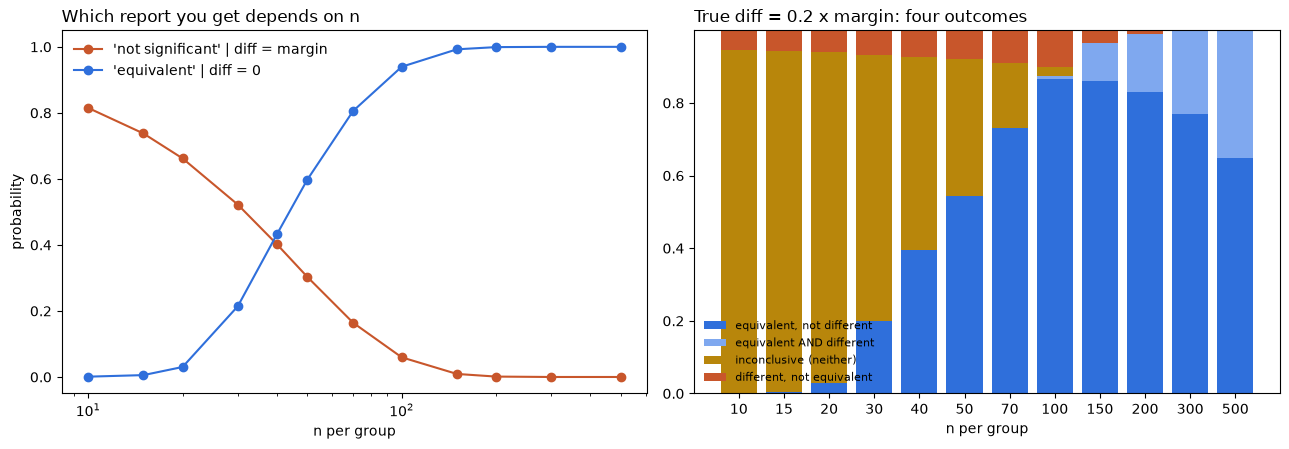

In [7]:
print(" n/group" + "".join(f"{LABEL[o]:>28}" for o in OUTCOMES))
for n in NS:
    print(f"{n:>7} " + "".join(f"{cell(n, 0.2)[o]:>28.4f}" for o in OUTCOMES))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ns_ = list(NS)
axes[0].plot(ns_, [cell(n, 1.0)["not_significant"] for n in ns_], "o-", color="#c8562b",
             label="'not significant' | diff = margin")
axes[0].plot(ns_, [cell(n, 0.0)["equivalent"] for n in ns_], "o-", color="#2f6fdb",
             label="'equivalent' | diff = 0")
axes[0].set_xscale("log"); axes[0].set_xlabel("n per group"); axes[0].set_ylabel("probability")
axes[0].legend(frameon=False); axes[0].set_title("Which report you get depends on n", loc="left")
bottom = np.zeros(len(ns_))
for o, c in zip(OUTCOMES, ("#2f6fdb", "#7fa8ef", "#b8860b", "#c8562b")):
    v = np.array([cell(n, 0.2)[o] for n in ns_])
    axes[1].bar(range(len(ns_)), v, bottom=bottom, color=c, label=LABEL[o])
    bottom += v
axes[1].set_xticks(range(len(ns_))); axes[1].set_xticklabels(ns_)
axes[1].set_xlabel("n per group"); axes[1].set_title("True diff = 0.2 x margin: four outcomes", loc="left")
axes[1].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

Small n: almost everything is **inconclusive**, which the t-test alone would have reported as
"no difference". Large n: a growing share is **equivalent AND different** (35% at n = 500) - the
difference is real and immaterial, and a t-test alone would have reported it as a finding.

## 7. One report, read properly

In [8]:
ex = exemplar()
print(f"seed {ex['seed']}: basket value, SD $20, margin $10, TRUE difference ${ex['true_delta']:.0f}, n = 20 a group")
print(f"observed difference ${ex['delta']:.2f}, t-test p = {ex['p_diff']:.4f}  -> 'no significant difference'")
print(f"TOST p = {ex['p_tost']:.4f}, 90% CI (${ex['ci90'][0]:.2f}, ${ex['ci90'][1]:.2f})  -> {ex['outcome']}")

seed 4: basket value, SD $20, margin $10, TRUE difference $10, n = 20 a group
observed difference $6.51, t-test p = 0.3449  -> 'no significant difference'
TOST p = 0.3052, 90% CI ($-4.96, $17.97)  -> inconclusive


The honest sentence is not "no difference". It is: *the study could not tell the two engines apart,
and at 20 baskets a group it was never going to - the interval still allows an $18 lift.*

## Summary

| claim | what it takes |
|---|---|
| "no significant difference" | nothing - a small study produces it 66% of the time for a difference that matters |
| "equivalent within +-M" (TOST) | the 90% CI inside +-M; about 70 per group at M = 0.5 SD |
| "not significant" as evidence | depends on n: worth 1.4x at n = 20, 100x at n = 150 |

## 8. Try your own

In [9]:
# control = [98.2, 104.1, 87.5, 110.3, 95.0, 101.7, 99.9, 92.4]
# new     = [101.5, 99.0, 105.2, 97.8, 108.1, 94.3, 103.6, 100.2]
# r = analyse(control, new, margin=10)
# print(r["outcome"], round(r["p_diff"], 4), round(r["p_tost"], 4), r["ci90"])
# print("n/group for 80% power at your margin:", n_for_power(0.8, 0.0, margin=0.3))
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/equivalence-test)

Streamlit version, where you paste your own two groups and margin:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`sample-size-calc`](../sample-size-calc) sizes a study to DETECT a difference;
[`p-value-dance`](../p-value-dance) measured how widely p moves across replays;
[`ci-overlap-fallacy`](../ci-overlap-fallacy) measured the eye reading error bars.